# TIỀN XỬ LÝ DỮ LIỆU

Notebook này thực hiện toàn bộ quá trình tiền xử lý dữ liệu bao gồm:

1. Đọc dữ liệu gốc.
2. Khảo sát và đánh giá chất lượng dữ liệu.
3. Làm sạch dữ liệu.
4. Xây dựng các thuộc tính mới (Feature Engineering).
5. Xuất bộ dữ liệu sạch phục vụ cho bước phân tích khám phá dữ liệu và xây dựng Dashboard.

## 1. Đọc dữ liệu gốc

In [1]:
# Tắt các cảnh báo không cần thiết
import warnings
warnings.filterwarnings("ignore")

# Xử lý biểu thức chính quy
import re

# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
from pathlib import Path

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Hiển thị đầy đủ các cột
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Thiết lập giao diện biểu đồ
plt.style.use("ggplot")

In [2]:
# Gộp các file dữ liệu gốc
import glob

# Tìm tất cả các file CSV trong thư mục raw
csv_files = sorted(glob.glob("../raw/cat*.csv"))
print(f"Tìm thấy {len(csv_files)} file CSV:")
for f in csv_files:
    print(f"  - {Path(f).name}")

# Gộp các file CSV lại thành 1 DataFrame
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

# Tách địa chỉ thành danh sách (thực hiện sớm để phục vụ điền khuyết Price ở mục 3.2)
address_parts = df["Address"].str.split(",")
df["Province"] = address_parts.apply(lambda x: x[0].strip() if isinstance(x, list) and len(x) > 0 else "Không xác định")
df["District"] = address_parts.apply(lambda x: x[1].strip() if isinstance(x, list) and len(x) > 1 else "Không xác định")
df["Detail"] = address_parts.apply(
    lambda x: ", ".join([part.strip() for part in x[2:]]) if isinstance(x, list) and len(x) > 2 else "Không xác định"
)


Tìm thấy 12 file CSV:
  - cat01_can_ho_chung_cu.csv
  - cat02_chung_cu_mini_chdv.csv
  - cat03_nha_rieng.csv
  - cat04_biet_thu_lien_ke.csv
  - cat05_nha_mat_pho.csv
  - cat06_shophouse.csv
  - cat07_dat_nen_du_an.csv
  - cat08_dat.csv
  - cat09_trang_trai_khu_nghi_duong.csv
  - cat10_condotel.csv
  - cat11_kho_nha_xuong.csv
  - cat12_bds_khac.csv


## 2. Khảo sát dữ liệu

Khảo sát tổng quan bộ dữ liệu nhằm đánh giá chất lượng dữ liệu trước khi thực hiện tiền xử lý.

### 2.1 Tổng quan bộ dữ liệu

In [3]:
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột : {df.shape[1]}")

# Hiển thị 5 dòng đầu tiên
df.head()

Số dòng: 3,996
Số cột : 15


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Xuân Mai Complex",62.0,NaN,NaN,NaN,NaN,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Xuân Mai Complex
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",61.0,NaN,NaN,Nam,Bắc,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội
2,"Hà Nội, Hà Đông, Căn hộ chung cư tại Park View Residence Dương Nội",52.0,NaN,NaN,Tây - Bắc,Đông - Nam,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Park View Residence Dương Nội
3,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Sparks",54.0,NaN,NaN,NaN,NaN,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Sparks
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",80.0,NaN,NaN,NaN,NaN,2.0,2.0,Have certificate,Full,NaN,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội


### 2.2 Danh sách các thuộc tính

In [4]:
pd.DataFrame({
    "Tên thuộc tính": df.columns
})

,Tên thuộc tính
0,Address
1,Area
2,Frontage
3,Access Road
4,House direction
5,Balcony direction
6,Bedrooms
7,Bathrooms
8,Legal status
9,Furniture state


### 2.3 Kiểm tra kiểu dữ liệu

In [5]:
# Thông tin tổng quan của bộ dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            3996 non-null   object 
 1   Area               3996 non-null   float64
 2   Frontage           2467 non-null   float64
 3   Access Road        2199 non-null   float64
 4   House direction    1845 non-null   object 
 5   Balcony direction  882 non-null    object 
 6   Bedrooms           1815 non-null   float64
 7   Bathrooms          1744 non-null   float64
 8   Legal status       3484 non-null   object 
 9   Furniture state    1268 non-null   object 
 10  Price              3659 non-null   float64
 11  Day                3996 non-null   int64  
 12  Province           3996 non-null   object 
 13  District           3996 non-null   object 
 14  Detail             3996 non-null   object 
dtypes: float64(6), int64(1), object(8)
memory usage: 468.4+ KB


In [6]:
# Thống kê số lượng từng kiểu dữ liệu
df.dtypes.value_counts()

object     8
float64    6
int64      1
Name: count, dtype: int64

### 2.4 Kiểm tra giá trị khuyết

In [7]:
# Thống kê số lượng và tỷ lệ giá trị thiếu
missing = pd.DataFrame({
    "Số lượng thiếu": df.isnull().sum(),
    "Tỷ lệ (%)": (df.isnull().mean() * 100).round(2)
})

missing = missing[missing["Số lượng thiếu"] > 0]

missing.sort_values(
    by="Tỷ lệ (%)",
    ascending=False
)

,Số lượng thiếu,Tỷ lệ (%)
Balcony direction,3114,77.93
Furniture state,2728,68.27
Bathrooms,2252,56.36
Bedrooms,2181,54.58
House direction,2151,53.83
Access Road,1797,44.97
Frontage,1529,38.26
Legal status,512,12.81
Price,337,8.43


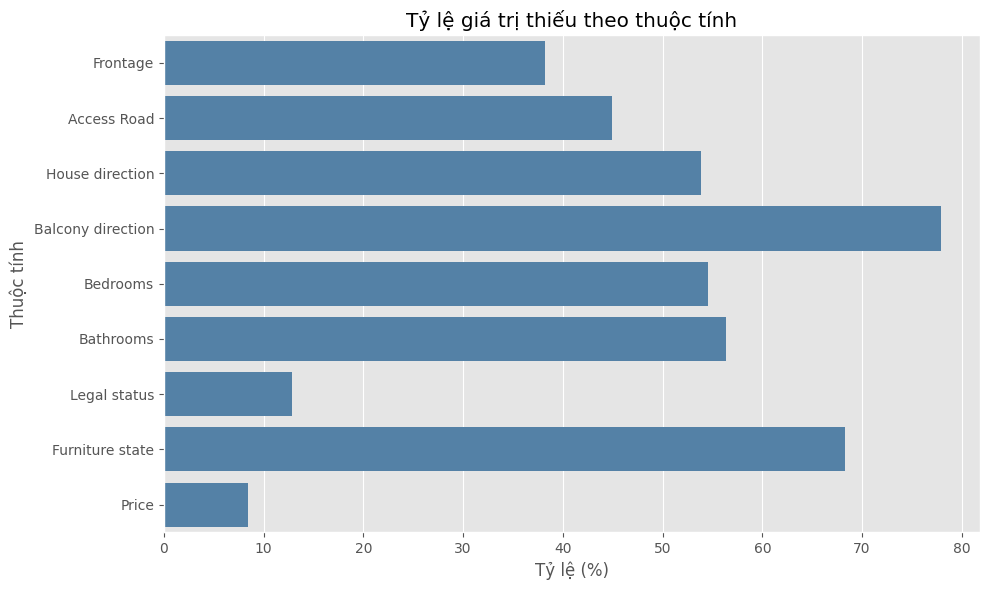

In [8]:
# Trực quan hóa tỷ lệ giá trị thiếu
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing.reset_index(),
    x="Tỷ lệ (%)",
    y="index",
    color="steelblue"
)

plt.title("Tỷ lệ giá trị thiếu theo thuộc tính")
plt.xlabel("Tỷ lệ (%)")
plt.ylabel("Thuộc tính")

plt.tight_layout()
plt.show()

### 2.5 Kiểm tra dữ liệu trùng lặp

In [9]:
duplicate_count = df.duplicated().sum()

print(f"Số dòng bị trùng lặp: {duplicate_count}")

# Hiển thị các dòng bị trùng (nếu có)
if duplicate_count > 0:
    display(df[df.duplicated()].head())
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Số dòng bị trùng lặp: 280


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail
63,"Hà Nội, Nam Từ Liêm, Căn hộ chung cư tại Vinhomes Smart City",32.00,NaN,NaN,NaN,NaN,1.0,1.0,Have certificate,Full,3.10,7,Hà Nội,Nam Từ Liêm,Căn hộ chung cư tại Vinhomes Smart City
67,"Hồ Chí Minh, Bình Thạnh, Căn hộ chung cư tại Sunwah Pearl",104.72,NaN,NaN,NaN,NaN,2.0,2.0,Sale contract,Basic,24.92,7,Hồ Chí Minh,Bình Thạnh,Căn hộ chung cư tại Sunwah Pearl
70,"Hưng Yên, Văn Giang, Căn hộ chung cư tại Khu đô thị Ecopark",152.00,NaN,NaN,NaN,Tây - Bắc,3.0,3.0,Have certificate,Full,14.00,3,Hưng Yên,Văn Giang,Căn hộ chung cư tại Khu đô thị Ecopark
72,"Hưng Yên, Văn Giang, Căn hộ chung cư tại Alumi - Alluvia City",114.93,NaN,NaN,Bắc,Bắc,3.0,3.0,Sale contract,Basic,8.81,3,Hưng Yên,Văn Giang,Căn hộ chung cư tại Alumi - Alluvia City
73,"Hưng Yên, Văn Giang, Căn hộ chung cư tại Alumi - Alluvia City",34.46,NaN,NaN,Nam,Bắc,1.0,1.0,Sale contract,Basic,2.54,3,Hưng Yên,Văn Giang,Căn hộ chung cư tại Alumi - Alluvia City


### 2.6 Kiểm tra giá trị của các thuộc tính

Thống kê số lượng giá trị khác nhau của từng thuộc tính và kiểm tra các thuộc tính dạng phân loại để phát hiện các giá trị chưa đồng nhất.

In [10]:
unique_summary = pd.DataFrame({
    "Thuộc tính": df.columns,
    "Số giá trị khác nhau": df.nunique().values
})

unique_summary = unique_summary.sort_values(
    by="Số giá trị khác nhau",
    ascending=False
).reset_index(drop=True)

unique_summary

,Thuộc tính,Số giá trị khác nhau
0,Address,2765
1,Detail,2602
2,Area,1201
3,Price,783
4,District,345
5,Frontage,262
6,Access Road,95
7,Province,59
8,Bedrooms,38
9,Bathrooms,34


In [11]:
#In ra giá trị và số lượng của các thuộc tính dạng categorical, để tìm ra phương án chuẩn hóa ở phần sau
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 80)
    print(df[col].value_counts(dropna=False))
    print()

Address
Bình Dương, Dĩ An, Bán đất tại đường Quốc lộ 1K                            24
Bà Rịa Vũng Tàu, Vũng Tàu, Condotel tại The Maris Vũng Tàu                 18
Hà Nội, Nam Từ Liêm, Căn hộ chung cư tại Vinhomes Smart City               17
Hồ Chí Minh, Cần Giờ, Nhà biệt thự, liền kề tại Vinhomes Green Paradise    15
Hà Nội, Gia Lâm, Nhà biệt thự, liền kề tại Vinhomes Ocean Park Gia Lâm     14
                                                                           ..
Vĩnh Phúc, Phúc Yên, Kho, nhà xưởng tại phường Phúc Thắng                   1
Bình Dương, Tân Uyên, Kho, nhà xưởng tại xã Tân Vĩnh Hiệp                   1
Hải Dương, Bình Giang, Kho, nhà xưởng tại xã Bình Xuyên                     1
Bình Dương, Bến Cát, Kho, nhà xưởng tại phường Hòa Lợi                      1
Đồng Nai, Nhơn Trạch, Kho, nhà xưởng tại đường 25C                          1
Name: count, Length: 2765, dtype: int64

House direction
NaN           2151
Đông - Nam     434
Đông - Bắc     280
Tây - Bắc      263
N

### 2.7 Thống kê mô tả

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,3996.0,2266.807069,79708.060234,1.0,68.645,100.0,200.00,5000000.0
Frontage,2467.0,12.777114,26.023552,2.5,5.000,6.0,11.80,800.0
Access Road,2199.0,13.824657,13.025121,1.0,6.000,10.0,17.00,200.0
Bedrooms,1815.0,4.618733,5.300359,1.0,2.000,3.0,5.00,75.0
Bathrooms,1744.0,4.385321,5.110768,1.0,2.000,3.0,5.00,55.0
Price,3659.0,21.204294,64.657398,0.0,2.500,6.6,16.95,999.0
Day,3996.0,20.663664,8.054383,1.0,17.000,23.0,26.00,30.0


### 2.8 Phát hiện giá trị ngoại lai

In [13]:
# Lấy danh sách các thuộc tính số
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Area', 'Frontage', 'Access Road', 'Bedrooms', 'Bathrooms', 'Price',
       'Day'],
      dtype='object')

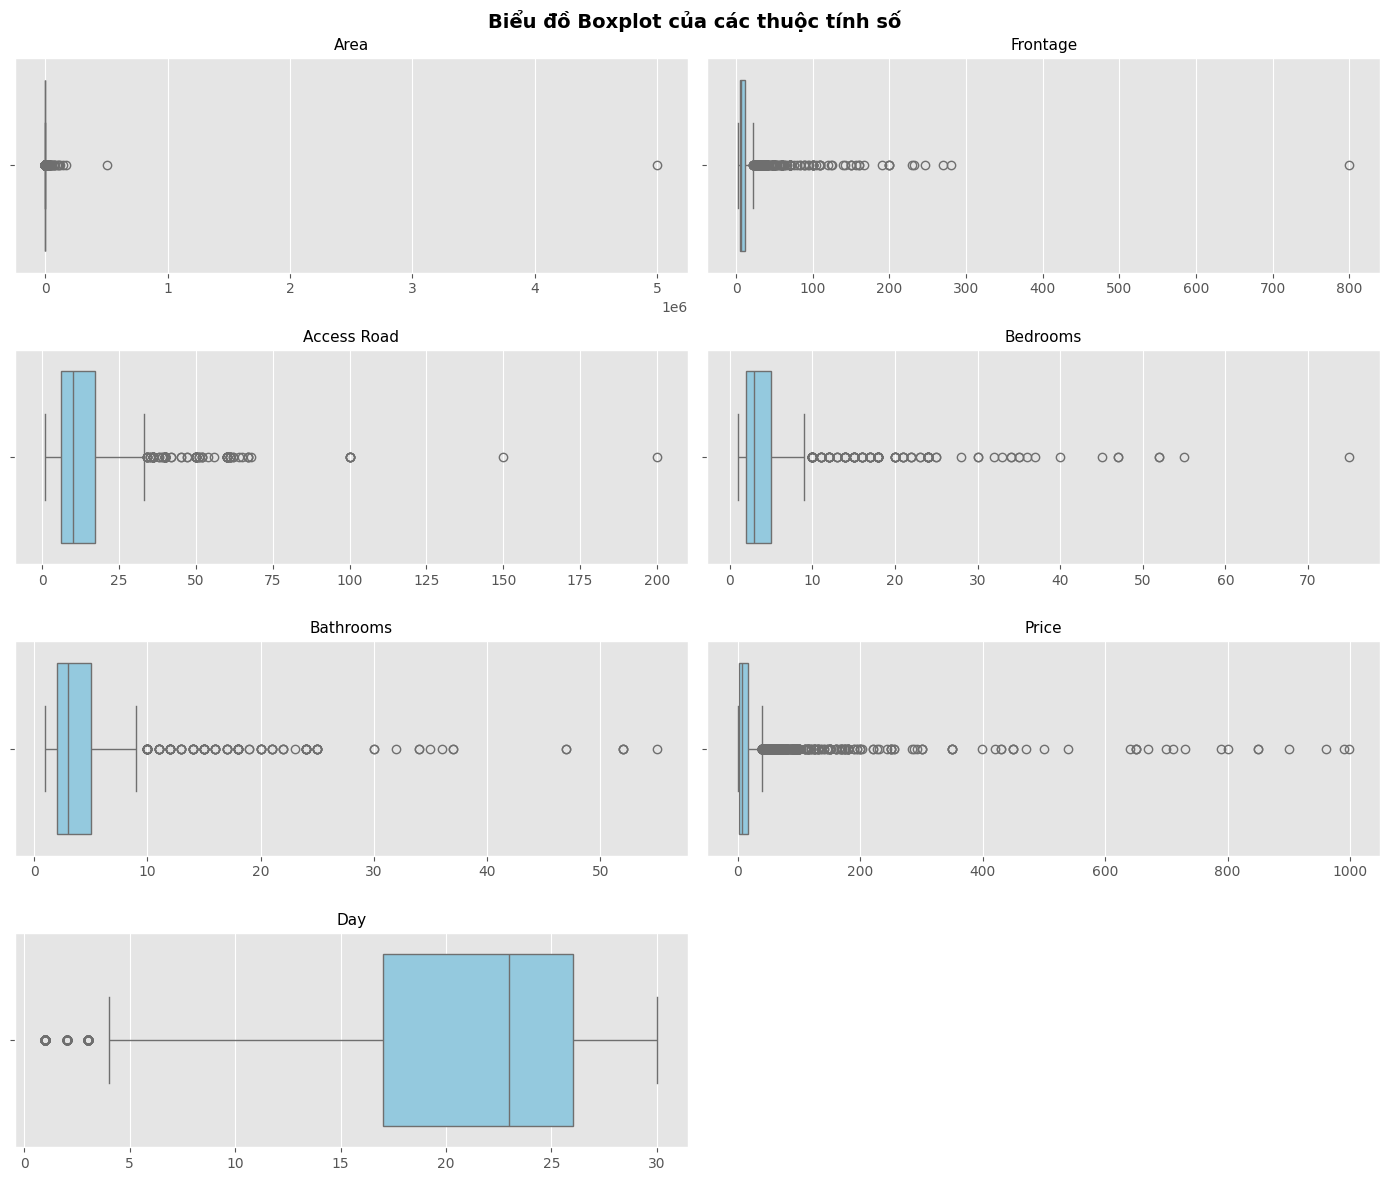

In [14]:
# Vẽ Boxplot cho các thuộc tính số theo dạng lưới 2 cột

numeric_cols = df.select_dtypes(include=np.number).columns

n_cols = 2
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3 * n_rows)
)

# Chuyển axes thành mảng 1 chiều để dễ duyệt
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color="skyblue"
    )

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

# Xóa các subplot thừa (nếu số cột lẻ)
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Biểu đồ Boxplot của các thuộc tính số", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.show()

## 3. Tiền xử lý dữ liệu

### 3.1 Xử lý dữ liệu trùng lắp

In [15]:
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Đã loại bỏ {duplicate_count} dòng dữ liệu trùng lặp.")
else:
    print("Không phát hiện dữ liệu trùng lặp.")

Đã loại bỏ 280 dòng dữ liệu trùng lặp.


### 3.2 Xử lý giá trị khuyết
- Đối với các thuộc tính dạng phân loại, các giá trị thiếu được thay thế bằng **"Không xác định"**.

- Đối với các thuộc tính dạng số, các giá trị thiếu được thay thế bằng **trung vị (Median)** nhằm giảm ảnh hưởng của các giá trị ngoại lai.

In [16]:
# Các cột phân loại
categorical_fill = {
    "House direction": "Không xác định",
    "Balcony direction": "Không xác định",
    "Legal status": "Không xác định",
    "Furniture state": "Không xác định"
}

# Thay thế giá trị thiếu của các cột phân loại
df.fillna(categorical_fill, inplace=True)

print("Đã xử lý giá trị thiếu cho các cột phân loại.")

Đã xử lý giá trị thiếu cho các cột phân loại.


In [17]:
# Các cột số cần xử lý giá trị thiếu (loại bỏ Floors)
numeric_fill = [
    "Frontage",
    "Access Road",
    "Bedrooms",
    "Bathrooms"
]

# Thay thế giá trị thiếu bằng trung vị của từng cột
for col in numeric_fill:
    df[col] = df[col].fillna(df[col].median())

print("Đã xử lý giá trị thiếu cho các cột số (Frontage, Access Road, Bedrooms, Bathrooms).")

Đã xử lý giá trị thiếu cho các cột số (Frontage, Access Road, Bedrooms, Bathrooms).


In [18]:
# Ước lượng và điền khuyết cho cột Price dựa trên đơn giá trung bình của khu vực (Quận/Huyện, Tỉnh/Thành)
df["temp_unit_price"] = df["Price"] / df["Area"]
district_means = df.groupby(["Province", "District"])["temp_unit_price"].transform("mean")
province_means = df.groupby("Province")["temp_unit_price"].transform("mean")
global_mean = df["temp_unit_price"].mean()

imputed_unit_price = district_means.fillna(province_means).fillna(global_mean)
null_price_mask = df["Price"].isna()
df.loc[null_price_mask, "Price"] = (df.loc[null_price_mask, "Area"] * imputed_unit_price).round(2)

# Xóa cột tạm
df.drop(columns=["temp_unit_price"], inplace=True, errors="ignore")

print(f"Đã ước lượng và điền khuyết cho {null_price_mask.sum()} dòng thiếu cột Price ở mục 3.2.")

Đã ước lượng và điền khuyết cho 309 dòng thiếu cột Price ở mục 3.2.


### 3.3 Chuẩn hóa dữ liệu
Thay đổi chuyển giá trị của các cột phân loại từ tiếng Anh thành tiếng Việt. 

In [19]:
# Chuẩn hóa tình trạng pháp lý
legal_mapping = {
    "Have certificate": "Đã có sổ",
    "Sale contract": "Hợp đồng mua bán"
}

df["Legal status"] = df["Legal status"].replace(legal_mapping)

print("Đã chuẩn hóa cột 'Legal status'.")

Đã chuẩn hóa cột 'Legal status'.


In [20]:
# Chuẩn hóa tình trạng nội thất
furniture_mapping = {
    "Full": "Đầy đủ",
    "Basic": "Cơ bản"
}

df["Furniture state"] = df["Furniture state"].replace(furniture_mapping)

print("Đã chuẩn hóa cột 'Furniture state'.")

Đã chuẩn hóa cột 'Furniture state'.


## 4. Xây dựng các thuộc tính mới (Feauture Engineering)

### 4.1 Tách thông tin địa chỉ

In [21]:
# Tách địa chỉ thành danh sách
address_parts = df["Address"].str.split(",")

# Tỉnh/Thành phố (phần tử đầu tiên)
df["Province"] = address_parts.apply(lambda x: x[0].strip() if isinstance(x, list) and len(x) > 0 else "Không xác định")

# Quận/Huyện (phần tử thứ hai)
df["District"] = address_parts.apply(lambda x: x[1].strip() if isinstance(x, list) and len(x) > 1 else "Không xác định")

# Chi tiết địa chỉ (các phần tử còn lại từ chỉ mục thứ hai trở đi)
df["Detail"] = address_parts.apply(
    lambda x: ", ".join([part.strip() for part in x[2:]]) if isinstance(x, list) and len(x) > 2 else "Không xác định"
)

print("Đã tách địa chỉ thành các cột 'Province', 'District' và 'Detail'.")


Đã tách địa chỉ thành các cột 'Province', 'District' và 'Detail'.


### 4.2 Tạo thuộc tính mới

In [22]:
# Giá trên mỗi mét vuông
df["Price_per_m2"] = (df["Price"]/df["Area"]).round(2)

print("Đã tạo thuộc tính 'Price_per_m2'.")


Đã tạo thuộc tính 'Price_per_m2'.


### 4.4 Phân nhóm dữ liệu
Trước khi phân nhóm, tiến hành khảo sát các mốc phân vị của từng thuộc tính nhằm xác định các khoảng giá trị đại diện cho phân bố dữ liệu. Các mốc này sau đó được làm tròn thành các ngưỡng dễ hiểu để sử dụng trong Dashboard.

In [23]:
# Các mốc phân vị của diện tích
area_quantiles = df["Area"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

area_quantiles

0.0          1.0
0.2         62.7
0.4         90.0
0.6        126.0
0.8        270.3
1.0    5000000.0
Name: Area, dtype: float64

In [24]:
area_bins = [0, 30, 50, 70, 90, np.inf]

area_labels = [
    "<30 m²",
    "30-50 m²",
    "50-70 m²",
    "70-90 m²",
    ">90 m²"
]

df["Area_Group"] = pd.cut(
    df["Area"],
    bins=area_bins,
    labels=area_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Area_Group'.")

Đã tạo thuộc tính 'Area_Group'.


In [25]:
# Các mốc phân vị của giá bán
price_quantiles = df["Price"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1])

price_quantiles

0.0         0.00
0.2         1.85
0.4         4.95
0.6        10.00
0.8        23.00
1.0    212662.58
Name: Price, dtype: float64

In [26]:
price_bins = [0, 4, 6, 8, 10, np.inf]

price_labels = [
    "<4 tỷ",
    "4-6 tỷ",
    "6-8 tỷ",
    "8-10 tỷ",
    ">10 tỷ"
]

df["Price_Segment"] = pd.cut(
    df["Price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

print("Đã tạo thuộc tính 'Price_Segment'.")

Đã tạo thuộc tính 'Price_Segment'.


In [27]:
# Kiểm tra thông tin dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3716 entries, 0 to 3995
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3716 non-null   object  
 1   Area               3716 non-null   float64 
 2   Frontage           3716 non-null   float64 
 3   Access Road        3716 non-null   float64 
 4   House direction    3716 non-null   object  
 5   Balcony direction  3716 non-null   object  
 6   Bedrooms           3716 non-null   float64 
 7   Bathrooms          3716 non-null   float64 
 8   Legal status       3716 non-null   object  
 9   Furniture state    3716 non-null   object  
 10  Price              3716 non-null   float64 
 11  Day                3716 non-null   int64   
 12  Province           3716 non-null   object  
 13  District           3716 non-null   object  
 14  Detail             3716 non-null   object  
 15  Price_per_m2       3716 non-null   float64 
 16  Area_Group 

### 4.5 Chuẩn hóa lại dữ liệu sau Feature Engineering

In [28]:
df['Province'].unique()

array(['Hà Nội', 'Quảng Ninh', 'Hồ Chí Minh', 'Hưng Yên', 'Khánh Hòa',
       'Bình Dương', 'Bắc Giang', 'Hải Phòng', 'Phú Thọ', 'Đà Nẵng',
       'Bà Rịa Vũng Tàu', 'Long An', 'Bình Thuận', 'Thừa Thiên Huế',
       'Thái Nguyên', 'Đồng Nai', 'Bắc Ninh', 'Cần Thơ', 'Bình Định',
       'Thanh Hóa', 'Hà Nam', 'Lào Cai', 'Thái Bình', 'Bến Tre',
       'Quảng Nam', 'Ninh Thuận', 'Lâm Đồng', 'Hòa Bình', 'Kiên Giang',
       'Tây Ninh', 'Vĩnh Long', 'Tuyên Quang', 'Bạc Liêu', 'An Giang',
       'Bình Phước', 'Cà Mau', 'Lạng Sơn', 'Tiền Giang', 'Phú Yên',
       'Đắk Lắk', 'Hải Dương', 'Nghệ An', 'Vĩnh Phúc', 'Trà Vinh',
       'Ninh Bình', 'Quảng Ngãi', 'Quảng Bình', 'Hà Tĩnh', 'Nam Định',
       'Yên Bái', 'Đồng Tháp', 'Quảng Trị', 'Sóc Trăng', 'Gia Lai',
       'Kon Tum', 'Sơn La', 'Hậu Giang', 'Hà Giang', 'Đắk Nông'],
      dtype=object)

Nhận thấy tên các tỉnh thành được viết dưới nhiều dạng, do đó cần tiền hành chuẩn hóa:

In [29]:
# Chuẩn hóa các tên được viết tắt 
province_mapping = {
    "TPHCM": "Hồ Chí Minh",
    "TpHCM": "Hồ Chí Minh",
    "TP. HCM": "Hồ Chí Minh",
    "TP Hồ Chí Minh": "Hồ Chí Minh",
    "Hồ Chí Mính": "Hồ Chí Minh",
    "HN": "Hà Nội",
    "Hà Nội": "Hà Nội",
}

df["Province"] = df["Province"].replace(province_mapping)

In [30]:
# Giữ lại tên tỉnh nếu phía sau có thêm mô tả

df.loc[
    df["Province"].str.contains("Hồ Chí Minh", na=False),
    "Province"
] = "Hồ Chí Minh"

df.loc[
    df["Province"].str.contains("Bình Dương", na=False),
    "Province"
] = "Bình Dương"

df.loc[
    df["Province"].str.contains("Quảng Ninh", na=False),
    "Province"
] = "Quảng Ninh"

In [31]:
# Một số giá trị thực chất là quận/thành phố trực thuộc

province_mapping = {
    "Quận Bình Thạnh": "Hồ Chí Minh",
    "Quận 8": "Hồ Chí Minh",
    "Quận Nam Từ Liêm": "Hà Nội",
    "TP. Cam Ranh": "Khánh Hòa"
}

df["Province"] = df["Province"].replace(province_mapping)

In [32]:
# Các giá trị không phải tên tỉnh/thành

invalid_province = [
    "Đường số 11",
    "giá 6ty",
    "Phòng công chứng Nguyễn Thị Thành",
    "Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt",
    "Hồ Chí Minh giá 2tỷ380"
]

df.loc[
    df["Province"].isin(invalid_province),
    "Province"
] = "Không xác định"

In [33]:
df['Province'].unique()

array(['Hà Nội', 'Quảng Ninh', 'Hồ Chí Minh', 'Hưng Yên', 'Khánh Hòa',
       'Bình Dương', 'Bắc Giang', 'Hải Phòng', 'Phú Thọ', 'Đà Nẵng',
       'Bà Rịa Vũng Tàu', 'Long An', 'Bình Thuận', 'Thừa Thiên Huế',
       'Thái Nguyên', 'Đồng Nai', 'Bắc Ninh', 'Cần Thơ', 'Bình Định',
       'Thanh Hóa', 'Hà Nam', 'Lào Cai', 'Thái Bình', 'Bến Tre',
       'Quảng Nam', 'Ninh Thuận', 'Lâm Đồng', 'Hòa Bình', 'Kiên Giang',
       'Tây Ninh', 'Vĩnh Long', 'Tuyên Quang', 'Bạc Liêu', 'An Giang',
       'Bình Phước', 'Cà Mau', 'Lạng Sơn', 'Tiền Giang', 'Phú Yên',
       'Đắk Lắk', 'Hải Dương', 'Nghệ An', 'Vĩnh Phúc', 'Trà Vinh',
       'Ninh Bình', 'Quảng Ngãi', 'Quảng Bình', 'Hà Tĩnh', 'Nam Định',
       'Yên Bái', 'Đồng Tháp', 'Quảng Trị', 'Sóc Trăng', 'Gia Lai',
       'Kon Tum', 'Sơn La', 'Hậu Giang', 'Hà Giang', 'Đắk Nông'],
      dtype=object)

In [34]:
# kiểm tra xem có giá trị thiếu trong cột Province không
df[df["Province"].isna()][["Address"]]

,Address


In [35]:
df[df["District"].isna()][["Address"]]

,Address


In [36]:
# Cột Ward đã bị lược bỏ do dataset mới không có Phường/Xã
# df[df["Ward"].isna()][["Address"]]


Trong quá trình tách thuộc tính `Address`, một số bản ghi không chứa đầy đủ thông tin địa chỉ (chỉ có tên đường, chỉ có quận/huyện hoặc là tiêu đề tin đăng). Đối với các trường hợp này, các thuộc tính không thể trích xuất được sẽ được gán giá trị **"Không xác định"** để đảm bảo tính nhất quán của bộ dữ liệu.

In [37]:
df["Province"] = df["Province"].replace(r"^\s*$", "Không xác định", regex=True)
df["District"] = df["District"].fillna("Không xác định")
df["Detail"] = df["Detail"].fillna("Không xác định")


### Chuẩn hóa cột District (Quận / Huyện)
Tên các quận/huyện trong dataset xuất hiện các biến thể khác nhau do tiền tố hành chính (như "Huyện", "Quận", "Thị xã", "Thành phố", "TP") hoặc cách viết hoa/thường không nhất quán (ví dụ: "Xuyên Mộc" và "Huyện Xuyên Mộc", "Thị xã Phú Mỹ" và "Thị Xã Phú Mỹ", "quận Tân Bình" và "Quận Tân Bình"). Cần chuẩn hóa về định dạng thống nhất.

In [38]:
# Chuẩn hóa tên Quận/Huyện trong cột District
import re

def clean_district(name):
    if not isinstance(name, str) or name.strip() in ("", "Không xác định", "nan"):
        return "Không xác định"
    s = name.strip()
    s = re.sub(r'\s+', ' ', s)
    # Loại bỏ các tiền tố hành chính nếu theo sau là tên tên riêng
    s_clean = re.sub(r'^(Huyện|Thị\s+[xX]ã|Quận|Thành\s+[pP]hố|TP\.?)\s+', '', s, flags=re.IGNORECASE).strip()
    
    # Nếu kết quả loại bỏ tiền tố chỉ chứa chữ số (ví dụ: '1', '2', '12'), giữ dạng 'Quận X'
    if s_clean.isdigit():
        return f"Quận {s_clean}"
    
    # Chuẩn hóa viết hoa chữ cái đầu mỗi từ
    words = s_clean.split(' ')
    s_clean = ' '.join([w.capitalize() if not w.isupper() else w for w in words])
    return s_clean

df["District"] = df["District"].apply(clean_district)
print(f"Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: {df['District'].nunique()}")

Đã chuẩn hóa cột District. Số giá trị unique sau chuẩn hóa: 344


In [39]:
# Kiểm tra thông tin dữ liệu sau khi xử lý
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3716 entries, 0 to 3995
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3716 non-null   object  
 1   Area               3716 non-null   float64 
 2   Frontage           3716 non-null   float64 
 3   Access Road        3716 non-null   float64 
 4   House direction    3716 non-null   object  
 5   Balcony direction  3716 non-null   object  
 6   Bedrooms           3716 non-null   float64 
 7   Bathrooms          3716 non-null   float64 
 8   Legal status       3716 non-null   object  
 9   Furniture state    3716 non-null   object  
 10  Price              3716 non-null   float64 
 11  Day                3716 non-null   int64   
 12  Province           3716 non-null   object  
 13  District           3716 non-null   object  
 14  Detail             3716 non-null   object  
 15  Price_per_m2       3716 non-null   float64 
 16  Area_Group 

In [40]:
df.isnull().sum()

Address              0
Area                 0
Frontage             0
Access Road          0
House direction      0
Balcony direction    0
Bedrooms             0
Bathrooms            0
Legal status         0
Furniture state      0
Price                0
Day                  0
Province             0
District             0
Detail               0
Price_per_m2         0
Area_Group           0
Price_Segment        0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

### 4.6 Ánh xạ tọa độ địa lý (Latitude, Longitude)

**1. Nguồn gốc của tọa độ hiện tại:**
- Các giá trị `Latitude` (Vĩ độ) và `Longitude` (Kinh độ) được tham chiếu từ **Hệ tọa độ Địa lý WGS84 (EPSG:4326)** chuẩn của **OpenStreetMap (OSM)** và **Tổng cục Thống kê (GSO)** Việt Nam.
- Mỗi Tỉnh/Thành phố được gán cặp tọa độ trọng tâm (Centroid WGS84) phục vụ hiển thị biểu đồ Choropleth Map và phân tích không gian địa lý.

In [42]:
# Bảng tọa độ vĩ độ (Latitude) và kinh độ (Longitude) trung tâm các Tỉnh/Thành phố Việt Nam
PROVINCE_COORDINATES = {
    "Hồ Chí Minh": (10.7769, 106.7009),
    "Hà Nội": (21.0285, 105.8542),
    "Bình Dương": (11.1604, 106.6508),
    "Đà Nẵng": (16.0544, 108.2022),
    "Đồng Nai": (10.9454, 106.8248),
    "Hải Phòng": (20.8449, 106.6881),
    "Khánh Hòa": (12.2388, 109.1967),
    "Hưng Yên": (20.6464, 106.0511),
    "Long An": (10.5360, 106.4099),
    "Bà Rịa Vũng Tàu": (10.4114, 107.1362),
    "Bắc Ninh": (21.1861, 106.0763),
    "Bình Thuận": (11.0904, 108.0722),
    "Lâm Đồng": (11.9404, 108.4583),
    "Quảng Ninh": (21.0069, 107.2925),
    "Cần Thơ": (10.0452, 105.7469),
    "Thanh Hóa": (19.8067, 105.7852),
    "Kiên Giang": (10.0125, 105.0809),
    "Đắc Lắc": (12.6667, 108.0500),
    "Đắk Lắk": (12.6667, 108.0500),
    "Hà Nam": (20.5453, 105.9126),
    "Bình Định": (13.7820, 109.2194),
    "Quảng Nam": (15.5667, 108.4833),
    "Hòa Bình": (20.8133, 105.3383),
    "Phú Thọ": (21.3167, 105.2167),
    "Vĩnh Phúc": (21.3083, 105.6042),
    "Lào Cai": (22.4856, 103.9707),
    "Thừa Thiên Huế": (16.4637, 107.5909),
    "Nghệ An": (19.2342, 104.8920),
    "Bắc Giang": (21.2731, 106.1946),
    "Tiền Giang": (10.4493, 106.3422),
    "Thái Bình": (20.4464, 106.3364),
    "Thái Nguyên": (21.5928, 105.8442),
    "Tây Ninh": (11.3601, 106.1098),
    "Phú Yên": (13.0882, 109.3087),
    "Ninh Thuận": (11.5653, 108.9882),
    "Hà Tĩnh": (18.3428, 105.9056),
    "Hải Dương": (20.9374, 106.3146),
    "Quảng Trị": (16.7444, 107.1855),
    "Gia Lai": (13.9833, 108.0000),
    "Bến Tre": (10.2415, 106.3758),
    "An Giang": (10.3759, 105.4185),
    "Quảng Ngãi": (15.1205, 108.7923),
    "Bình Phước": (11.7500, 106.9167),
    "Sơn La": (21.3256, 103.9188),
    "Lạng Sơn": (21.8537, 106.7610),
    "Nam Định": (20.4200, 106.1683),
    "Yên Bái": (21.7167, 104.8833),
    "Vĩnh Long": (10.2537, 105.9722),
    "Trà Vinh": (9.9347, 106.3453),
    "Đồng Tháp": (10.4578, 105.6322),
    "Cà Mau": (9.1769, 105.1500),
    "Điện Biên": (21.3833, 103.0167),
    "Sóc Trăng": (9.6033, 105.9800),
    "Ninh Bình": (20.2506, 105.9745),
    "Bạc Liêu": (9.2941, 105.7244),
    "Tuyên Quang": (21.8242, 105.2158),
    "Hà Giang": (22.8233, 104.9839),
    "Hậu Giang": (9.7844, 105.4701),
    "Quảng Bình": (17.4690, 106.6227),
    "Kon Tum": (14.3500, 108.0000),
    "Cao Bằng": (22.6667, 105.9167),
    "Lai Châu": (22.4000, 103.4500),
    "Bắc Kạn": (22.1472, 105.8347),
    "Đắk Nông": (12.2500, 107.6833),
}

df["Latitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[0])
df["Longitude"] = df["Province"].map(lambda p: PROVINCE_COORDINATES.get(p, (np.nan, np.nan))[1])


## 5. Xuất dữ liệu sạch

In [43]:
# Đường dẫn lưu bộ dữ liệu đã tiền xử lý
output_path = "../processed/house_price_clean.csv"

# Xuất dữ liệu
df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Đã xuất dữ liệu thành công tới: {output_path}")

Đã xuất dữ liệu thành công tới: ../processed/house_price_clean.csv


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3716 entries, 0 to 3995
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Address            3716 non-null   object  
 1   Area               3716 non-null   float64 
 2   Frontage           3716 non-null   float64 
 3   Access Road        3716 non-null   float64 
 4   House direction    3716 non-null   object  
 5   Balcony direction  3716 non-null   object  
 6   Bedrooms           3716 non-null   float64 
 7   Bathrooms          3716 non-null   float64 
 8   Legal status       3716 non-null   object  
 9   Furniture state    3716 non-null   object  
 10  Price              3716 non-null   float64 
 11  Day                3716 non-null   int64   
 12  Province           3716 non-null   object  
 13  District           3716 non-null   object  
 14  Detail             3716 non-null   object  
 15  Price_per_m2       3716 non-null   float64 
 16  Area_Group 

In [45]:
df.head()

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Bedrooms,Bathrooms,Legal status,Furniture state,Price,Day,Province,District,Detail,Price_per_m2,Area_Group,Price_Segment,Latitude,Longitude
0,"Hà Nội, Hà Đông, Căn hộ chung cư tại Xuân Mai Complex",62.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,11.33,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Xuân Mai Complex,0.18,50-70 m²,>10 tỷ,21.0285,105.8542
1,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",61.0,6.0,10.0,Nam,Bắc,2.0,2.0,Đã có sổ,Đầy đủ,11.15,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.18,50-70 m²,>10 tỷ,21.0285,105.8542
2,"Hà Nội, Hà Đông, Căn hộ chung cư tại Park View Residence Dương Nội",52.0,6.0,10.0,Tây - Bắc,Đông - Nam,2.0,2.0,Đã có sổ,Đầy đủ,9.51,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Park View Residence Dương Nội,0.18,50-70 m²,8-10 tỷ,21.0285,105.8542
3,"Hà Nội, Hà Đông, Căn hộ chung cư tại The Sparks",54.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,9.87,1,Hà Nội,Hà Đông,Căn hộ chung cư tại The Sparks,0.18,50-70 m²,8-10 tỷ,21.0285,105.8542
4,"Hà Nội, Hà Đông, Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội",80.0,6.0,10.0,Không xác định,Không xác định,2.0,2.0,Đã có sổ,Đầy đủ,14.62,1,Hà Nội,Hà Đông,Căn hộ chung cư tại Khu nhà ở Bộ tư lệnh Thủ đô Hà Nội,0.18,70-90 m²,>10 tỷ,21.0285,105.8542
